<a href="https://colab.research.google.com/github/Yashzope/EDA_PracT/blob/main/edaPract3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [201]:
from scipy import stats
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm, t
from scipy.stats import expon
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot,show,title ,xlabel,ylabel
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
from statsmodels.tsa.seasonal import seasonal_decompose as ssd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from statsmodels.tsa.api import Holt
from statsmodels.tsa.api import SimpleExpSmoothing
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from math import sqrt
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller

In [264]:
df1 = pd.read_csv('/content/drive/MyDrive/AAS_data/Employee_Master.csv')
df2 = pd.read_csv('/content/drive/MyDrive/AAS_data/Monthly_Performance.csv')
df3= pd.read_csv('/content/drive/MyDrive/AAS_data/Engagement_Survey.csv')
df20 = pd.read_csv('/content/drive/MyDrive/AAS_data/Monthly_Performance.csv')


In [203]:
df1.head()

,EmployeeID,Gender,Department,Experience,Salary,ExitInterviewCompleted,Attrition
0,E00001,Female,IT,2,72951.0,No,0
1,E00002,Female,Sales,11,44283.0,Yes,1
2,E00003,Female,Sales,14,59367.0,No,0
3,E00004,Female,HR,4,78754.0,No,0
4,E00005,Female,IT,5,82069.0,No,0


In [204]:
df2.head()

,EmployeeID,Sales_Jan,Sales_Feb,Sales_Mar,Sales_Apr,Sales_May,Sales_Jun,Sales_Jul,Sales_Aug,Sales_Sep,Sales_Oct,Sales_Nov,Sales_Dec
0,E00001,86.4,93.7,79.2,78.3,92.4,83.0,92.8,79.2,77.0,77.4,83.3,78.4
1,E00002,94.5,72.4,87.2,78.7,102.8,75.8,84.8,62.5,84.1,87.9,89.2,78.9
2,E00003,106.8,95.1,104.2,107.7,107.8,108.6,104.8,109.9,106.5,94.6,93.2,102.0
3,E00004,96.8,87.2,91.6,94.8,78.2,91.8,91.2,96.2,99.9,102.4,93.6,90.6
4,E00005,86.0,83.2,100.8,82.2,91.4,97.4,103.7,88.3,83.6,82.0,92.7,91.0


In [205]:
df3.head()

,EmployeeID,WorkLifeBalance,JobSatisfaction
0,E00001,Good,Medium
1,E00002,Good,High
2,E00003,Poor,Medium
3,E00004,Poor,High
4,E00005,Average,High


How many records and variables are present in each of the three datasets?


In [206]:
df1.shape

(1000, 7)

In [207]:
df2.shape

(1000, 13)

In [208]:
df3.shape

(1000, 3)

In [209]:
'''
Idenfy the role of each variable. Which variables appear to be:
 Numerical
 Categorical
 Idenfier variables
 Potenal target variables
'''

'\nIden\x10fy the role of each variable. Which variables appear to be:\n\uf0b7 Numerical\n\uf0b7 Categorical\n\uf0b7 Iden\x10fier variables\n\uf0b7 Poten\x10al target variables\n'

In [210]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   EmployeeID              1000 non-null   object 
 1   Gender                  1000 non-null   object 
 2   Department              1000 non-null   object 
 3   Experience              1000 non-null   int64  
 4   Salary                  950 non-null    float64
 5   ExitInterviewCompleted  1000 non-null   object 
 6   Attrition               1000 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


In [211]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmployeeID  1000 non-null   object 
 1   Sales_Jan   1000 non-null   float64
 2   Sales_Feb   1000 non-null   float64
 3   Sales_Mar   1000 non-null   float64
 4   Sales_Apr   1000 non-null   float64
 5   Sales_May   1000 non-null   float64
 6   Sales_Jun   1000 non-null   float64
 7   Sales_Jul   1000 non-null   float64
 8   Sales_Aug   920 non-null    float64
 9   Sales_Sep   1000 non-null   float64
 10  Sales_Oct   1000 non-null   float64
 11  Sales_Nov   920 non-null    float64
 12  Sales_Dec   1000 non-null   float64
dtypes: float64(12), object(1)
memory usage: 101.7+ KB


In [212]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EmployeeID       1000 non-null   object
 1   WorkLifeBalance  940 non-null    object
 2   JobSatisfaction  1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB


In [213]:
df1.dtypes

,0
EmployeeID,object
Gender,object
Department,object
Experience,int64
Salary,float64
ExitInterviewCompleted,object
Attrition,int64


In [214]:
df2.dtypes

,0
EmployeeID,object
Sales_Jan,float64
Sales_Feb,float64
Sales_Mar,float64
Sales_Apr,float64
Sales_May,float64
Sales_Jun,float64
Sales_Jul,float64
Sales_Aug,float64
Sales_Sep,float64


In [215]:
df3.dtypes

,0
EmployeeID,object
WorkLifeBalance,object
JobSatisfaction,object


In [216]:
#Which dataset appears to contain employee-level informaon? df1

In [217]:
#Which dataset appears to contain repeated measurements over me? df2

In [218]:
#'''Q5 What is the business meaning of the Attrition on variable?------->Attrition in business refers to the intentional reduction of a company's workforce through voluntary departures such as resignations, retirements, or career changes, without immediate replacement.'''

In [219]:
df1['Attrition'].value_counts()

,count
Attrition,
0,800
1,200


In [220]:
#What percentage of employees have left the company?

(df1['Attrition'].value_counts())/len(df1)*100

,count
Attrition,
0,80.0
1,20.0


In [221]:
#Is the target variable balanced or imbalanced? Explain your conclusion:imbalanced


Phase 2: Data Quality Assessment


In [222]:
#Are there missing values in any of the datasets? : YES

In [223]:
df1.isnull().sum()

,0
EmployeeID,0
Gender,0
Department,0
Experience,0
Salary,50
ExitInterviewCompleted,0
Attrition,0


In [224]:
df2.isnull().sum()

,0
EmployeeID,0
Sales_Jan,0
Sales_Feb,0
Sales_Mar,0
Sales_Apr,0
Sales_May,0
Sales_Jun,0
Sales_Jul,0
Sales_Aug,80
Sales_Sep,0


In [225]:
df1['Salary']= df1['Salary'].fillna(df1['Salary'].median)

In [226]:
df1.isnull().sum()

,0
EmployeeID,0
Gender,0
Department,0
Experience,0
Salary,0
ExitInterviewCompleted,0
Attrition,0


In [227]:
df2.isnull().sum()

,0
EmployeeID,0
Sales_Jan,0
Sales_Feb,0
Sales_Mar,0
Sales_Apr,0
Sales_May,0
Sales_Jun,0
Sales_Jul,0
Sales_Aug,80
Sales_Sep,0


In [228]:
df2['Sales_Nov'] = df2['Sales_Nov'].fillna(df2['Sales_Nov'].median)

In [229]:
df2['Sales_Aug'] = df2['Sales_Aug'].fillna(df2['Sales_Aug'].median)

In [230]:
df2.isnull().sum()

,0
EmployeeID,0
Sales_Jan,0
Sales_Feb,0
Sales_Mar,0
Sales_Apr,0
Sales_May,0
Sales_Jun,0
Sales_Jul,0
Sales_Aug,0
Sales_Sep,0


In [231]:
df3['WorkLifeBalance'].value_counts()

,count
WorkLifeBalance,
Average,417
Good,289
Poor,234


In [232]:
df3.isnull().sum()

,0
EmployeeID,0
WorkLifeBalance,60
JobSatisfaction,0


In [233]:
df3['WorkLifeBalance'] = df3['WorkLifeBalance'].fillna(df3['WorkLifeBalance'].mode)

In [234]:
df3.isnull().sum()

,0
EmployeeID,0
WorkLifeBalance,0
JobSatisfaction,0


In [235]:
'''Which variables contain missing values?
df1:  Salary
df2:  Sales_Aug,Sales_Nov
df3:  WorkLifeBalance
'''

'Which variables contain missing values?\ndf1:  Salary\ndf2:  Sales_Aug,Sales_Nov\ndf3:  WorkLifeBalance\n'

In [236]:
#What percentage of observaons is missing for each variable?

In [237]:
(df1.isnull().sum())/len(df1)*100

,0
EmployeeID,0.0
Gender,0.0
Department,0.0
Experience,0.0
Salary,0.0
ExitInterviewCompleted,0.0
Attrition,0.0


In [238]:
(df2.isnull().sum())/len(df2)*100

,0
EmployeeID,0.0
Sales_Jan,0.0
Sales_Feb,0.0
Sales_Mar,0.0
Sales_Apr,0.0
Sales_May,0.0
Sales_Jun,0.0
Sales_Jul,0.0
Sales_Aug,0.0
Sales_Sep,0.0


In [239]:
(df3.isnull().sum())/len(df3)*100

,0
EmployeeID,0.0
WorkLifeBalance,0.0
JobSatisfaction,0.0


In [240]:
#Are there any unusual or extreme values in the performance-related variables?

In [241]:
df2.describe()

,Sales_Jan,Sales_Feb,Sales_Mar,Sales_Apr,Sales_May,Sales_Jun,Sales_Jul,Sales_Sep,Sales_Oct,Sales_Dec
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000
mean,91.033600,90.972500,91.059100,91.032000,91.314200,91.64670,91.494500,91.712300,90.82960,91.556600
std,21.220042,21.064614,20.817994,21.258148,21.430292,21.97459,21.904204,22.150475,22.47201,23.517459
min,28.700000,29.200000,31.100000,36.800000,23.100000,20.00000,28.700000,22.700000,28.70000,20.800000
25%,77.475000,76.800000,77.475000,77.175000,77.975000,77.67500,77.575000,77.775000,76.07500,76.975000
50%,89.850000,90.050000,89.700000,90.500000,90.850000,90.65000,90.600000,90.600000,90.05000,90.250000
75%,103.325000,102.600000,103.500000,103.800000,103.825000,103.80000,104.100000,105.000000,105.12500,104.925000
max,208.600000,221.600000,229.600000,207.000000,238.800000,246.20000,236.800000,247.600000,233.40000,242.600000


In [242]:
df2.columns

Index(['EmployeeID', 'Sales_Jan', 'Sales_Feb', 'Sales_Mar', 'Sales_Apr',
       'Sales_May', 'Sales_Jun', 'Sales_Jul', 'Sales_Aug', 'Sales_Sep',
       'Sales_Oct', 'Sales_Nov', 'Sales_Dec'],
      dtype='object')

<Axes: >

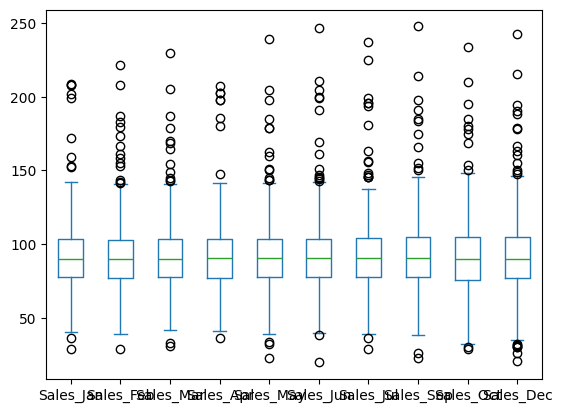

In [243]:
df2[['EmployeeID', 'Sales_Jan', 'Sales_Feb', 'Sales_Mar', 'Sales_Apr',
       'Sales_May', 'Sales_Jun', 'Sales_Jul', 'Sales_Aug', 'Sales_Sep',
       'Sales_Oct', 'Sales_Nov', 'Sales_Dec']].plot(kind='box')

Phase 3: Data Restructuring


In [244]:
#Is the Monthly_Performance dataset stored in a format that is suitable for analysis?:yes

In [245]:
df2.columns

Index(['EmployeeID', 'Sales_Jan', 'Sales_Feb', 'Sales_Mar', 'Sales_Apr',
       'Sales_May', 'Sales_Jun', 'Sales_Jul', 'Sales_Aug', 'Sales_Sep',
       'Sales_Oct', 'Sales_Nov', 'Sales_Dec'],
      dtype='object')

In [246]:
pd.melt(df2,id_vars='EmployeeID',var_name = 'Month',value_name='Sales')

,EmployeeID,Month,Sales
0,E00001,Sales_Jan,86.4
1,E00002,Sales_Jan,94.5
2,E00003,Sales_Jan,106.8
3,E00004,Sales_Jan,96.8
4,E00005,Sales_Jan,86.0
...,...,...,...
11995,E00996,Sales_Dec,64.3
11996,E00997,Sales_Dec,101.7
11997,E00998,Sales_Dec,178.4
11998,E00999,Sales_Dec,115.9


In [247]:
df2 = pd.melt(df2,id_vars='EmployeeID',var_name='Month',value_name='Sales')

In [248]:
df2= df2.sort_values('EmployeeID').reset_index(drop=True)

In [249]:
#Afer restructuring the data, how many rows and columns are present?
df2.shape

(12000, 3)

In [250]:
'''What advantages does the new structure provide for feature engineering? ->:easy to analyze '''

'What advantages does the new structure provide for feature engineering? ->:easy to analyze '

Phase 4: Feature Engineering


In [251]:
df2.dtypes

,0
EmployeeID,object
Month,object
Sales,object


In [252]:
df2['Sales'] = pd.to_numeric(df2['Sales'], errors='coerce')

In [253]:
df2.dtypes

,0
EmployeeID,object
Month,object
Sales,float64


In [254]:
'''Can a single measure be created to represent the average sales performance of each employee
across all months? '''

'Can a single measure be created to represent the average sales performance of each employee\nacross all months? '

In [255]:
avg_sales_perf = df2.groupby('EmployeeID')['Sales'].mean()

In [256]:
avg_sales_perf.head()

,Sales
EmployeeID,
E00001,83.425000
E00002,83.233333
E00003,103.433333
E00004,92.858333
E00005,90.191667


In [257]:
#Can a measure be created to capture the variability in sales performance?

In [258]:
df2.groupby('EmployeeID')['Sales'].std()

,Sales
EmployeeID,
E00001,6.380813
E00002,10.565496
E00003,5.902439
E00004,6.245647
E00005,7.384438
...,...
E00996,8.449435
E00997,5.718093
E00998,19.094113


In [ ]:
'''Can a measure be created to indicate whether an employee's performance has improved or
deteriorated over me?'''

In [268]:
perrf = df20['Sales_Dec']-df20['Sales_Jan']

In [274]:
perrf

,0
0,-8.0
1,-15.6
2,-4.8
3,-6.2
4,5.0
...,...
995,-7.8
996,3.6
997,26.2
998,15.2


In [ ]:
'''Can employees be classified into high-performing and non-high-performing groups using sales
informaon? '''

In [275]:
np.where(perrf > 0)   #performed well
'is sales are more in dec as compared to jan so the final difference should be in positive or greater then 0'

(array([  4,   8,   9,  10,  13,  15,  16,  17,  18,  20,  22,  23,  25,
         27,  28,  29,  31,  34,  36,  37,  41,  44,  47,  50,  52,  54,
         55,  56,  60,  61,  64,  67,  70,  72,  73,  75,  79,  80,  81,
         83,  85,  87,  90,  91,  92,  93,  94,  97,  99, 100, 101, 104,
        106, 108, 111, 112, 113, 115, 117, 119, 120, 122, 123, 126, 130,
        131, 132, 134, 135, 136, 139, 145, 146, 148, 149, 150, 151, 152,
        153, 156, 160, 161, 162, 167, 168, 169, 171, 172, 174, 175, 179,
        181, 183, 184, 186, 187, 188, 193, 194, 195, 196, 197, 199, 200,
        203, 204, 205, 206, 207, 209, 212, 213, 214, 215, 218, 219, 220,
        221, 222, 224, 225, 230, 231, 232, 233, 235, 236, 237, 238, 242,
        243, 244, 246, 247, 248, 250, 252, 254, 256, 258, 259, 261, 262,
        265, 266, 267, 268, 269, 270, 271, 272, 273, 275, 277, 278, 281,
        284, 285, 287, 292, 294, 297, 298, 299, 300, 302, 304, 305, 309,
        313, 314, 316, 317, 318, 323, 325, 327, 333

In [276]:
np.where(perrf < 0 )      #showed poor performance

(array([  0,   1,   2,   3,   5,   6,   7,  11,  12,  14,  19,  21,  24,
         26,  30,  32,  33,  35,  38,  39,  40,  42,  43,  45,  46,  48,
         49,  51,  53,  57,  58,  59,  62,  63,  65,  66,  68,  69,  71,
         74,  76,  77,  78,  82,  84,  86,  88,  89,  95,  96,  98, 102,
        103, 105, 107, 109, 110, 114, 116, 118, 121, 124, 125, 127, 128,
        129, 133, 137, 138, 140, 141, 142, 143, 144, 147, 154, 155, 157,
        158, 159, 163, 164, 165, 166, 170, 173, 176, 177, 178, 180, 182,
        185, 189, 190, 191, 192, 198, 201, 202, 208, 210, 211, 216, 217,
        223, 226, 227, 228, 229, 234, 239, 240, 241, 245, 249, 251, 253,
        255, 257, 260, 263, 264, 274, 276, 279, 280, 282, 283, 286, 288,
        289, 290, 291, 293, 295, 296, 301, 303, 306, 307, 308, 310, 311,
        312, 315, 319, 320, 321, 322, 324, 326, 328, 329, 330, 331, 332,
        335, 337, 341, 342, 344, 345, 347, 348, 350, 354, 355, 362, 367,
        368, 369, 373, 374, 375, 376, 377, 379, 381

In [270]:
df20.head()

,EmployeeID,Sales_Jan,Sales_Feb,Sales_Mar,Sales_Apr,Sales_May,Sales_Jun,Sales_Jul,Sales_Aug,Sales_Sep,Sales_Oct,Sales_Nov,Sales_Dec
0,E00001,86.4,93.7,79.2,78.3,92.4,83.0,92.8,79.2,77.0,77.4,83.3,78.4
1,E00002,94.5,72.4,87.2,78.7,102.8,75.8,84.8,62.5,84.1,87.9,89.2,78.9
2,E00003,106.8,95.1,104.2,107.7,107.8,108.6,104.8,109.9,106.5,94.6,93.2,102.0
3,E00004,96.8,87.2,91.6,94.8,78.2,91.8,91.2,96.2,99.9,102.4,93.6,90.6
4,E00005,86.0,83.2,100.8,82.2,91.4,97.4,103.7,88.3,83.6,82.0,92.7,91.0


In [271]:
df2.head(50)

,EmployeeID,Sales_Jan,Sales_Feb,Sales_Mar,Sales_Apr,Sales_May,Sales_Jun,Sales_Jul,Sales_Aug,Sales_Sep,Sales_Oct,Sales_Nov,Sales_Dec
0,E00001,86.4,93.7,79.2,78.3,92.4,83.0,92.8,79.2,77.0,77.4,83.3,78.4
1,E00002,94.5,72.4,87.2,78.7,102.8,75.8,84.8,62.5,84.1,87.9,89.2,78.9
2,E00003,106.8,95.1,104.2,107.7,107.8,108.6,104.8,109.9,106.5,94.6,93.2,102.0
3,E00004,96.8,87.2,91.6,94.8,78.2,91.8,91.2,96.2,99.9,102.4,93.6,90.6
4,E00005,86.0,83.2,100.8,82.2,91.4,97.4,103.7,88.3,83.6,82.0,92.7,91.0
5,E00006,94.2,99.9,100.4,86.7,97.6,103.1,92.9,94.0,98.8,95.8,91.7,90.6
6,E00007,86.2,79.2,84.5,75.6,92.0,72.6,77.5,77.8,80.1,72.5,81.1,59.5
7,E00008,74.3,75.7,74.6,75.4,79.4,69.4,78.0,84.0,77.5,70.1,67.7,68.3
8,E00009,114.1,122.9,140.8,128.5,119.2,115.9,126.2,126.6,131.2,118.3,113.9,120.0
9,E00010,89.4,83.7,72.2,67.1,82.0,97.2,76.1,85.4,83.2,88.0,76.9,95.1


In [272]:
df1.head()

,EmployeeID,Gender,Department,Experience,Salary,ExitInterviewCompleted,Attrition
0,E00001,Female,IT,2,72951.0,No,0
1,E00002,Female,Sales,11,44283.0,Yes,1
2,E00003,Female,Sales,14,59367.0,No,0
3,E00004,Female,HR,4,78754.0,No,0
4,E00005,Female,IT,5,82069.0,No,0


In [273]:
df3.head()

,EmployeeID,WorkLifeBalance,JobSatisfaction
0,E00001,Good,Medium
1,E00002,Good,High
2,E00003,Poor,Medium
3,E00004,Poor,High
4,E00005,Average,High
